<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/exercises/01b_dynamics%2BJAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamics, trajectories, and JAX

In this notebook, we will see how to use `JAX` to perform everything we did in notebook 1a, but with additional features and improved performance.

`JAX` not only allows us to seamlessly use NumPy-like operations through `jax.numpy`, but it also provides powerful tools for automatic differentiation, efficient computation, and linearizing dynamics.

As you work through this notebook, fill in the code using only `jax` and `jax.numpy`. Be sure to consult the `jax.numpy` documentation for correct usage, as there can sometimes be subtle differences compared to classic NumPy.

Let’s dive in and explore how `JAX` can accelerate and enhance our computations!

## 0. Getting familiar with `jax` and `jax.numpy`.



In [22]:
import jax
import jax.numpy as jnp
import equinox as eqx

### Arrays with `jax.numpy`

`jax.numpy` (typically imported as `jnp`) is a drop-in replacement for NumPy. You create arrays the same way:

In [23]:
# Create arrays (same API as NumPy)
a = jnp.array([1.0, 2.0, 3.0])
b = jnp.array([[1, 2], [3, 4]])
c = jnp.zeros((2, 3))
d = jnp.linspace(0, 1, 5)

print("1D array:", a)
print("2D array:\n", b)
print("Zeros:\n", c)
print("Linspace:", d)

1D array: [1. 2. 3.]
2D array:
 [[1 2]
 [3 4]]
Zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
Linspace: [0.   0.25 0.5  0.75 1.  ]


### Random arrays with `jax.random`

JAX uses **explicit PRNG keys** for random number generation (unlike NumPy's global state). You create a key, then pass it to functions like `jax.random.uniform` or `jax.random.normal`. Use `jax.random.split` to get new keys for each call:

In [24]:
key = jax.random.PRNGKey(0)  # seed 0

# Uniform in [0, 1) and standard normal
u = jax.random.uniform(key, shape=(3, 2))
key, subkey = jax.random.split(key)  # split to get a new key for next call
z = jax.random.normal(subkey, shape=(3, 2))

print("Uniform [0,1):\n", u)
print("Standard normal:\n", z)

Uniform [0,1):
 [[0.57450044 0.09968603]
 [0.7419659  0.8941783 ]
 [0.59656656 0.45325184]]
Standard normal:
 [[-1.4581939 -2.047044 ]
 [-1.4242861  1.1684095]
 [-0.9758364 -1.2718494]]


### `jax.vmap` — vectorizing functions

`jax.vmap` (vectorizing map) automatically "batches" a function so it runs over many inputs in parallel. Instead of writing a loop, you write a function for a single input and `vmap` handles the batch:

In [25]:
# Function that takes a single vector and returns a scalar
def norm_squared(x):
    return jnp.sum(x**2)

# vmap: apply norm_squared to each row of a batch of vectors
x_batch = jnp.array([[1.0, 0.0], [1.0, 1.0], [3.0, 4.0]])  # shape (3, 2)
norm_squared_batched = jax.vmap(norm_squared)
result = norm_squared_batched(x_batch)  # shape (3,) — one value per row
print("Input shape:", x_batch.shape)
print("Output:", result)  # [1, 2, 25]

Input shape: (3, 2)
Output: [ 1.  2. 25.]


### `jax.grad` — automatic differentiation

`jax.grad` computes the gradient of a scalar-valued function with respect to its arguments. You define the function; JAX computes the derivatives:

In [26]:
def loss(x):
    return jnp.sum(x**2)  # scalar

# grad(loss) returns a function that computes d(loss)/d(x)
grad_loss = jax.grad(loss)
x = jnp.array([1.0, 2.0, 3.0])
print("loss(x):", loss(x))
print("grad(loss)(x):", grad_loss(x))  # 2*x = [2, 4, 6]

loss(x): 14.0
grad(loss)(x): [2. 4. 6.]


### `jax.jacobian` — Jacobian matrix

`jax.jacobian` computes the Jacobian matrix of a vector-valued function: the matrix of partial derivatives of each output with respect to each input. Use `argnums` to specify which arguments to differentiate with respect to:

In [27]:
def f(x):
    """Vector-valued function: R^2 -> R^2"""
    return jnp.array([x[0]**2 + x[1], x[0] * x[1]])

# Jacobian: (output_dim, input_dim) = (2, 2)
J = jax.jacobian(f)(jnp.array([1.0, 2.0]))
print("f(x) at x=[1,2]:", f(jnp.array([1.0, 2.0])))
print("Jacobian J = df/dx:\n", J)
# J[0,:] = d/dx of first output = [2*x[0], 1]
# J[1,:] = d/dx of second output = [x[1], x[0]]

f(x) at x=[1,2]: [3. 2.]
Jacobian J = df/dx:
 [[2. 1.]
 [2. 1.]]


### `jax.jit` — just-in-time compilation

`jax.jit` compiles a function to optimized machine code (via XLA), so repeated calls run much faster. The first call triggers compilation; later calls use the cached result. Works great with `grad`, `vmap`, and other JAX transforms:

In [28]:
def slow_fn(x):
    return jnp.sum(jnp.sin(x) ** 2)

fast_fn = jax.jit(slow_fn)

x = jnp.linspace(0, 10, 10000)
# First call: compiles (may be slower). Later calls: fast!
result = fast_fn(x)
print("Result:", result)

Result: 4771.4346


In [29]:
import time

def f(x):
    return jnp.sum(jnp.sin(x) ** 2)

batch_size, dim = 5000, 50
x_batch = jnp.ones((batch_size, dim))

# vmap only
vmapped = jax.vmap(f)
_ = vmapped(x_batch).block_until_ready()  # warmup

# jit + vmap
jit_vmapped = jax.jit(jax.vmap(f))
_ = jit_vmapped(x_batch).block_until_ready()  # compile + warmup

# Benchmark
n = 1000
start = time.perf_counter()
for _ in range(n):
    _ = vmapped(x_batch).block_until_ready()
no_jit_time = time.perf_counter() - start

start = time.perf_counter()
for _ in range(n):
    _ = jit_vmapped(x_batch).block_until_ready()
jit_time = time.perf_counter() - start

print(f"vmap only:  {no_jit_time:.4f}s ({n} runs)")
print(f"jit + vmap: {jit_time:.4f}s ({n} runs)")
print(f"Speedup:    {no_jit_time / jit_time:.1f}x")

vmap only:  1.4719s (1000 runs)
jit + vmap: 0.6347s (1000 runs)
Speedup:    2.3x


## Try it out yourself!
Consider the functions.

$$ f(x,y) = x^2 * y + 4 * \sin(xy), \quad x,y\in\mathbb{R} $$

$$ g(z) = \begin{bmatrix} z_2 \\ z_1^2 \\ z_2 z_3 - z_1 \end{bmatrix}, \quad z\in\mathbb{R}^3 $$




In [30]:
def f(x, y):
    return x**2 * y + 4 * jnp.sin(x * y)

def g(z):
    return jnp.array([z[1], z[0]**2, z[1] * z[2] - z[0]])


### (a) Generate input batches
Generate random values for $x$, $y$, and $z$ to use as inputs for the next exercises.

- Create batched inputs `x_batch`, `y_batch`, and `z_batch`, where the batch size is 128.
  - `x_batch`: shape (128,)
  - `y_batch`: shape (128,)
  - `z_batch`: shape (128, 3)

- Additionally, generate single random values for each variable:
  - `x_single`: shape ()
  - `y_single`: shape ()
  - `z_single`: shape (3,)

You may use any PRNG key and any distribution of your choice (e.g., normal or uniform) for random number generation.


In [31]:
# TODO: compute the required inputs
###### add your code here
key = jax.random.PRNGKey(100)  # seed 100
key, subkey = jax.random.split(key)  # split to get a new key for next call
subsubkey, subkey = jax.random.split(subkey)

x_batch = jax.random.normal(key, shape=(128,))
y_batch = jax.random.normal(subkey, shape=(128,))
z_batch = jax.random.normal(subsubkey, shape=(128,3))
x_single = jax.random.normal(key, shape=())
y_single = jax.random.normal(subkey, shape=())
z_single = jax.random.normal(subsubkey, shape=(3,))

# print("x_batch:\n", x_batch)
# print("y_batch:\n", y_batch)
# print("z_batch:\n", z_batch)
# print("x_single:\n", x_single)
# print("y_single:\n", y_single)
# print("z_single:\n", z_single)
###### end of add your code here


### (b) Using `jax.vmap` for Vectorization

Read the documentation for `jax.vmap`, paying special attention to the purpose and usage of the `in_axes` argument.

Your task: Use `jax.vmap` to vectorize the provided functions and evaluate them on various batched and singleton inputs, as follows:

- Compute `f(x_single, y_batch)` (vectorize over `y_batch` while keeping `x_single` fixed).
- Compute `f(x_batch, y_single)` (vectorize over `x_batch` while keeping `y_single` fixed).
- Compute `f(x_batch, y_batch)` (vectorize jointly over both `x_batch` and `y_batch`).
- Compute `g(z_batch)` (vectorize over the batch of `z` inputs).

For each computation, ensure you leverage the `in_axes` argument correctly to specify which dimensions are to be mapped over.

In [32]:
# TODO: compute the required function evaluations
###### add your code here

## vectorize over y_batch while keeping x_single fixed
# we want to keep x_single static (its a scalar) and map over 
# the first axis of the y_batch (there is only one axis), so 
# in_axes = (None, 0)
f_x_single_y_batch = jax.vmap(f, (None, 0))

## vectorize over x_batch while keeping y_single fixed
# now we want to map over x and keep y static, so
# in_axes = (0, None)
f_x_batch_y_single = jax.vmap(f, (0, None))

## vectorize jointly over both x_batch and y_batch
f_x_batch_y_batch = jax.vmap(f, (0,0))

# vectorize over the batch of z inputs
# this function takes a 3D vector (z). the z_batch is (128,3), 
# so we want to map 128 function calls for each row vector input
# in_axes is then just the first axes (in_axes = 0) to map over
# the 128 rows.
g_z_batch = jax.vmap(g, 0)

###### end of add your code here


### (c) Apply `jax.grad`

Review the documentation for `jax.grad`, focusing on how to specify which argument to differentiate with respect to using the `argnums` parameter.
Your task: Using `jax.grad`, compute the following partial derivatives of the function `f` at the points `x_single` and `y_single`:
- $\frac{\partial f}{\partial x}$: the derivative of `f` with respect to its first argument (`x`)
- $\frac{\partial f}{\partial y}$: the derivative of `f` with respect to its second argument (`y`)

You should evaluate both quantities at the given values of `x_single` and `y_single`.

In [33]:
# TODO: compute the required function evaluations
###### add your code here
grad_x_f = jax.grad(f,0)
grad_y_f = jax.grad(f,1)
print(grad_x_f(x_single, y_single))
print(grad_y_f(x_single, y_single))
###### end of add your code here



-2.2683692
-1.5914884


### (d) Compute the Jacobian of $g$

Use `jax.jacobian` to compute the Jacobian matrix $\frac{\partial g}{\partial z}$ of the function $g$ evaluated at the point `z_single` (the single $z$ value you created in part (i)).


In [34]:
# TODO: compute the Jacobian of g at z_single
###### add your code here
J_g = jax.jacobian(g)
print(J_g(z_single))
###### end of add your code here

[[ 0.          1.          0.        ]
 [-0.8156249   0.          0.        ]
 [-1.          0.22579299  0.37060603]]


### (e) Use `jax.vmap` to compute gradients and Jacobians on batched inputs

Using `jax.vmap` in combination with `jax.grad` and `jax.jacobian`, perform the following computations efficiently over the batched inputs from part (i):

- Compute the gradients $\frac{\partial f}{\partial x}$ and $\frac{\partial f}{\partial y}$ for each pair $(x, y)$ in the batches `x_batch` and `y_batch`.
- Compute the Jacobian matrix $\frac{\partial g}{\partial z}$ for each $z$ in the batch `z_batch`.

Ensure your code returns arrays with the computed gradients and Jacobians for all elements in the input batches.

In [35]:
# TODO: compute batched gradients and Jacobians using vmap
###### add your code here

# compute df/dx for each x,y pair
grad_f_x_batch = jax.vmap(grad_x_f, (0,0))
computed_gradf_xbatch = grad_f_x_batch(x_batch, y_batch)
print(f"df/dx (gradient) batched:\n\t{computed_gradf_xbatch}\n")

# compute df/dy for each x,y pair
grad_f_y_batch = jax.vmap(grad_y_f, (0,0))
computed_gradf_ybatch = grad_f_y_batch(x_batch, y_batch)
print(f"df/dy (gradient) batched:\n\t{computed_gradf_ybatch}\n")

# compute jacobian dg/dz for each z
J_g_batch = jax.vmap(J_g, 0)
computed_jacobian_zbatch = J_g_batch(z_batch)
print(f"dg/dz (jacobian) batched:\nshape:{jnp.shape(computed_jacobian_zbatch)}\n\t{computed_jacobian_zbatch}\n")
###### end of add your code here



df/dx (gradient) batched:
	[-4.0734320e+00 -3.6901102e+00  3.7476671e+00 -2.0281925e+00
 -7.0876803e+00 -2.8871102e+00 -6.2404841e-02 -3.5987675e+00
 -4.8059201e-01  1.3502645e+00  1.6090447e+00  3.3223577e+00
  2.1791925e+00  1.1869066e+00  9.9152470e-01 -2.9065096e-01
  1.8115928e+00 -2.7923965e+00 -2.5165019e+00 -3.1576002e+00
 -1.2526065e-01  3.8779285e+00 -1.6764057e+00 -2.6989949e+00
 -3.5162696e-01  1.2195108e+01 -3.3673065e+00  2.3054488e+00
  5.6967540e+00  9.4740346e-02 -2.0848227e+00 -2.9100304e+00
 -6.8800921e+00  7.5753558e-01 -3.8640308e+00  2.8339827e-01
  3.8707465e-01 -2.8785646e+00  2.1533935e+00  2.4503634e+00
 -6.6139202e+00  8.4516120e-01  8.2514000e-01 -6.6049159e-01
 -8.7904930e-03  2.4148148e-01 -6.7808878e-01  3.5828510e-01
  4.4479222e+00 -6.3375640e-01 -5.8487844e+00 -1.6565244e+00
 -5.5145497e+00 -1.0158302e+01  2.1240475e+00  3.4847012e+00
 -9.6257534e+00  4.0712881e+00  1.1520526e+01 -1.5110729e+00
 -2.1527154e+00  1.9802412e+00 -8.6632395e+00 -2.2200911e+

### (f) Use `jax.lax.scan` to iterate a function

`jax.lax.scan` provides an efficient way to iterate a function while maintaining a carried state—ideal for tasks like simulating system dynamics over multiple steps without explicit Python loops. Its core signature is `scan(f, init, xs)`, where the function `f(carry, x)` returns a new carry and an output at each step. You can find more details in the [JAX documentation](https://jax.readthedocs.io/en/latest/_autosummary/jax.lax.scan.html).

Your task:
- Use `jax.lax.scan` to iteratively apply the function $g$ starting from the initial value $z_0 =$ `z_single`. For $k$ from $0$ to $n$ (a total of $n+1$ steps), compute the sequence defined by $z_{k+1} = g(z_k)$.
- Collect and return the full trajectory of the $z$ values in an array named `z_trajectory`, which should have shape `(n+1, 3)`.

Next, write a standard Python for loop which performs the same iteration (without using `jax.lax.scan`), and verifies that the outputs from both approaches are identical.

In [36]:
# TODO: use jax.lax.scan to iterate g starting from z_single

###### add your code here

def lax_scan_loop(z0, n_steps):
    def step(z, _):
        g_next = g(z)
        return g_next, g_next
    _, zs = jax.lax.scan(step, z0, None, length=n_steps)
    z_trajectory = jnp.concatenate([z0[None,:], zs])
    return z_trajectory

def regular_for_loop(z0, n_steps):
    zs = [z0]
    for i in range(n_steps):
        zs.append(g(zs[i]))
    z_trajectory = jnp.stack(zs) # each z value (array) is a row
    return z_trajectory

###### end of add your code here



In [37]:
n_steps = 100
zs_scan = lax_scan_loop(z_single, n_steps)
zs_for = regular_for_loop(z_single, n_steps)

# print(zs_for)
print(jnp.allclose(zs_scan, zs_for))


True


Let's quickly compare the computation time.

In [38]:
n_steps = 1000

In [39]:
%timeit lax_scan_loop(z_single, n_steps)

37.3 ms ± 1.94 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [40]:

%timeit regular_for_loop(z_single, n_steps)


1.29 s ± 176 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### (g) `jax.jit` and `eqx.filter_jit` — JIT compilation with static arguments

`jax.jit` is a powerful tool that compiles Python functions for significant speedups in JAX.
You can use it either as a decorator (`@jax.jit`) or as a function wrapper (`jax.jit(fn)`).
When your function takes **static** arguments—such as Python `int`, `str`, or configuration objects—that should not be traced by JAX,
you must specify them with `static_argnums` or `static_argnames`.
This is especially important for arguments that control shapes, loop counts, or other compile-time logic.

`eqx.filter_jit` from the Equinox library provides a more convenient JIT workflow. It automatically detects
which arguments are JAX/NumPy arrays (to be traced), and treats all other types as static,
so you usually do not need to manually specify `static_argnums`.

You task: Use the `lax_scan_loop` function you implemented previously.

1. Create `lax_scan_loop_jit` by wrapping `lax_scan_loop` with `jax.jit`, specifying `static_argnums=(1,)`
   because `n_steps` (argument 1) is a static Python integer (used as the scan length).
2. Create `lax_scan_loop_filter_jit` by wrapping `lax_scan_loop` with `eqx.filter_jit`.
   (Here, you do not need to specify any static arguments—`eqx.filter_jit` automatically treats Python integers as static.)
3. Repeat steps 1 and 2 with the `regular_for_loop` function (`regular_for_loop_jit` via `jax.jit`, and `regular_for_loop_filter_jit` via `eqx.filter_jit`).

Write the code to define these jitted versions of your functions.

In [41]:
# TODO: apply jax.jit and eqx.filter_jit to lax_scan_loop
###### add your code here
# 1.
lax_scan_loop_jit = jax.jit(lax_scan_loop, static_argnums=1)

# 2.
lax_scan_loop_filter_jit = eqx.filter_jit(lax_scan_loop)

# 3. 
regular_for_loop_jit = jax.jit(regular_for_loop, static_argnums=1)

# 4. 
regular_for_loop_filter_jit = eqx.filter_jit(regular_for_loop)

###### end of add your code here



Let's compare the timing of these jitted and non-jitted functions

In [42]:
n_steps = 100
# Warmup (first call triggers JIT compilation)
_ = lax_scan_loop_jit(z_single, n_steps).block_until_ready()
_ = lax_scan_loop_filter_jit(z_single, n_steps).block_until_ready()

print("lax_scan (no JIT):")
%timeit lax_scan_loop(z_single, n_steps).block_until_ready()
print("\nlax_scan_jit (jax.jit):")
%timeit lax_scan_loop_jit(z_single, n_steps).block_until_ready()
print("\nlax_scan_loop_filter_jit (eqx.filter_jit):")
%timeit lax_scan_loop_filter_jit(z_single, n_steps).block_until_ready()
print("\nregular_for_loop (no JIT):")
%timeit regular_for_loop(z_single, n_steps).block_until_ready()
print("\nregular_for_loop_jit (jax.jit):")
%timeit regular_for_loop_jit(z_single, n_steps).block_until_ready()
print("\nregular_for_loop_filter_jit (eqx.filter_jit):")
%timeit regular_for_loop_filter_jit(z_single, n_steps).block_until_ready()


lax_scan (no JIT):
35.3 ms ± 1.25 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

lax_scan_jit (jax.jit):
16.3 μs ± 162 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

lax_scan_loop_filter_jit (eqx.filter_jit):
292 μs ± 2.09 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

regular_for_loop (no JIT):
110 ms ± 554 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

regular_for_loop_jit (jax.jit):
80 μs ± 16.4 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)

regular_for_loop_filter_jit (eqx.filter_jit):
398 μs ± 62.3 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


### (h) Combine `jax.jit`, `jax.vmap`, and `jax.grad`

JAX transformation functions (such as `jax.jit`, `jax.vmap`, and `jax.grad`) can be naturally composed with one another.
In this part, you will combine these transformations to create efficient, JIT-compiled, batched computations for derivatives from part (e).

Specifically, implement the following:

1. `batched_grad_f_jit`: Use `jax.vmap` and `jax.grad` to compute the gradients $\frac{\partial f}{\partial x}$ and $\frac{\partial f}{\partial y}$ for each pair $(x, y)$ in `(x_batch, y_batch)`.
   Then, apply `jax.jit` to JIT-compile the batched version.
2. `batched_jacobian_g_jit`: Use `jax.vmap` and `jax.jacobian` to compute the Jacobian $\frac{\partial g}{\partial z}$ for each $z$ in `z_batch`, and JIT-compile this batched computation with `jax.jit`.

After implementing these functions, verify that they produce the same results as the corresponding non-jitted versions from part (v).

In [43]:
# TODO: combine jit, vmap, and grad/jacobian
###### add your code here
# jax.grad(f, (0,1)) takes the gradient with respect to BOTH inputs
# then we map that over the first (and only) axis (axis 0) for both inputs, 
# which will be x_batch and y_batch
# lastly, we jit it
batched_grad_f_jit = jax.jit( jax.vmap(jax.grad(f, argnums=(0,1)), in_axes=(0,0)) )
jit_computed_batched_grad_f_jit = batched_grad_f_jit(x_batch, y_batch)
print(jnp.shape(jit_computed_batched_grad_f_jit))

batched_jacobian_g_jit = jax.jit( jax.vmap( jax.jacobian(g,0), in_axes=0) )
jit_computed_batched_jacobian_g = batched_jacobian_g_jit(z_batch)
print(jnp.shape(jit_computed_batched_jacobian_g))
# Verify: compare with grad_f_x_batch, grad_f_y_batch, J_g_batch from part (v)

print(jnp.allclose(jit_computed_batched_grad_f_jit[0], computed_gradf_xbatch))
print(jnp.allclose(jit_computed_batched_grad_f_jit[1], computed_gradf_ybatch))
print(jnp.allclose(jit_computed_batched_jacobian_g, computed_jacobian_zbatch))
###### end of add your code here



(2, 128)
(128, 3, 3)
True
True
True


Compare the timing with your non-jitted implementation from (e)

In [44]:
# Non-jitted versions from part (v)
batched_grad_f = jax.vmap(jax.grad(f, argnums=[0, 1]), in_axes=(0, 0))
batched_jacobian_g = jax.vmap(jax.jacobian(g))

# Warmup (first call triggers JIT compilation)
_ = batched_grad_f_jit(x_batch, y_batch)[0].block_until_ready()
_ = batched_jacobian_g_jit(z_batch).block_until_ready()

print("Batched gradients of f (no JIT):")
%timeit batched_grad_f(x_batch, y_batch)[0].block_until_ready()
print("\nBatched gradients of f (jitted):")
%timeit batched_grad_f_jit(x_batch, y_batch)[0].block_until_ready()
print("\nBatched Jacobians of g (no JIT):")
%timeit batched_jacobian_g(z_batch).block_until_ready()
print("\nBatched Jacobians of g (jitted):")
%timeit batched_jacobian_g_jit(z_batch).block_until_ready()

Batched gradients of f (no JIT):
5.63 ms ± 120 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Batched gradients of f (jitted):
11.2 μs ± 266 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

Batched Jacobians of g (no JIT):
15.2 ms ± 392 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Batched Jacobians of g (jitted):
10.7 μs ± 2.26 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Now that you have an idea of how `JAX` works, you will now repeat the problems from notebook 1a, but use `JAX` to help speed up the computation.

## 1. Dynamics and trajectories

First, let's import the relevant packages

In [45]:
import abc
from typing import Callable
import matplotlib.pyplot as plt
import functools
import math

# import jax and jax.numpy. No regular numpy needed anymore!
import jax
import jax.numpy as jnp

*TIP:* Use `jax.numpy` as you would `numpy`—for most operations, just replace `np` with `jnp`.

*JIT Compilation:*
  - To speed up functions, apply `@jax.jit` or the more convenient `@eqx.filter_jit` decorator above your function definitions.
  - If you need to pass static (non-array) arguments to a jitted function using `jax.jit`, use `functools.partial` to specify `static_argnums` (see below for an example).
  - `eqx.filter_jit` will automatically trace JAX/NumPy array arguments, treating all others as static—helpful for flexible code.

See example usage below.


In [46]:
# This will not work since y is static (not a float)
@jax.jit
def test_function(x, y=True):
    if y:
        return x
    else:
        return x**2

# this will work
@functools.partial(jax.jit, static_argnums=(1,))
def test_function2(x, y=True):
    if y:
        return x
    else:
        return x**2

# this will work. eqx.filter_jit will automatically treat JAX/NumPy arrays as traced and all other types as static
@eqx.filter_jit
def test_function3(x, y=True):
    if y:
        return x
    else:
        return x**2

x = jnp.ones((8, 4)) * 2.0
# test_function(x, False) # this will throw an error
test_function2(x, False) # this will work
test_function3(x, False) # this will work


Array([[4., 4., 4., 4.],
       [4., 4., 4., 4.],
       [4., 4., 4., 4.],
       [4., 4., 4., 4.],
       [4., 4., 4., 4.],
       [4., 4., 4., 4.],
       [4., 4., 4., 4.],
       [4., 4., 4., 4.]], dtype=float32)

Let's now define a base class for representing the dynamics of a system.

Carefully review the Dynamics class below, as you'll build upon and use it in the following sections.

In [47]:
class Dynamics(metaclass=abc.ABCMeta):
    """Abstract base class for dynamical systems."""

    dynamics_func: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray]
    state_dim: int
    control_dim: int

    def __init__(
        self,
        dynamics_func: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray],
        state_dim: int,
        control_dim: int,
    ):
        """Initializes the Dynamics object.

        Args:
            dynamics_func: A callable representing the dynamics function.
            state_dim: The dimension of the state space.
            control_dim: The dimension of the control space.
        """
        self.dynamics_func = dynamics_func
        self.state_dim = state_dim
        self.control_dim = control_dim

    @eqx.filter_jit
    def __call__(
        self, state: jnp.ndarray, control: jnp.ndarray, time: float = 0.0
    ) -> jnp.ndarray:
        """Evaluates the dynamics function at a given state, control, and time.
        For continuous time dynamics, we have x_dot = f(x, u, t)
        For discrete time dynamics, we have x_{k+1} = f(x_k, u_k, t_k)

        Args:
            state: The current state.
            control: The current control input.
            time: The current time (optional, defaults to 0).

        Returns:
            The next state.
        """
        return self.dynamics_func(state, control, time)

###  (a) Discretizing Continuous-Time Dynamics

To simulate or control physical systems on a computer, we often need to convert continuous-time dynamics into discrete-time dynamics by integrating over a fixed time step $\Delta t$.
In this section, you will derive discrete-time dynamics from continuous-time models using two different numerical integration methods:
- Euler integration (a simple, first-order method)
- Runge-Kutta integration (specifically, the more accurate fourth-order RK4 method)
Implement both integration techniques to obtain the discrete-time dynamics.


#### (i) Implement Euler integation to obtain the discrete-time dynamics.

In [48]:
@eqx.filter_jit
def euler_integrate(
    dynamics: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray], dt: float
) -> Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray]:
    """
    Implement Euler integration for discrete-time dynamics.

    Args:
        dynamics: A callable representing the continuous-time dynamics function.
        dt: The time step for integration.

    Returns:
        A callable representing the discrete-time dynamics using Euler integration.
    """

    # zero-order hold
    def integrator(x: jnp.ndarray, u: jnp.ndarray, t: float) -> jnp.ndarray:

        # TODO: Implement Euler integration here
        ###### add your code here
        x_next = x + dynamics(x,u,t) * dt
        return x_next
        ###### end of add your code here


    return integrator

#### (ii) Implement runge-Kutta integration to obtain the discrete-time dynamics.

In [49]:
@eqx.filter_jit
def runge_kutta_integrate(
    dynamics: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray], dt: float
) -> Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray]:
    """
    Implement Runge-Kutta integration for discrete-time dynamics.

    Args:
        dynamics: A callable representing the continuous-time dynamics function.
        dt: The time step for integration.

    Returns:
        A callable representing the discrete-time dynamics using Runge-Kutta integration.
    """

    # zero-order hold
    def integrator(x: jnp.ndarray, u: jnp.ndarray, t: float) -> jnp.ndarray:

        # TODO: Implement Runge-Kutta integration here
        ###### add your code here
        dt2 = dt/2 # pre-compute dt/2 for efficiency
        k1 = dynamics(x, u, t)
        k2 = dynamics(x + dt2*k1, u, t + dt2)
        k3 = dynamics(x + dt2*k2, u, t + dt2)
        k4 = dynamics(x + dt*k3, u, t + dt)
        x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        return x_next
        ###### end of add your code here


    return integrator

### (b) Defining the Dynamically Extended Unicycle Dynamics
In this section, you will work with the dynamically extended unicycle model.

Your task is to use the previously defined `Dynamics` class to construct the continuous-time dynamics for this model.

The continuous-time state vector is given by
$$
    \mathbf{x} = \begin{bmatrix}
        x \\ y \\ \theta \\ v
    \end{bmatrix}
$$
where $x$, $y$ represent position, $\theta$ is the heading angle, and $v$ is the velocity.

The control input is
$$
    \mathbf{u} = \begin{bmatrix}
        \omega \\ a
    \end{bmatrix}
$$
where $\omega$ is the turn rate and $a$ is the acceleration.

The continuous-time dynamics can be written as:
$$
    \dot{\mathbf{x}} = \begin{bmatrix}
        \dot{x} \\ \dot{y} \\ \dot{\theta} \\ \dot{v}
    \end{bmatrix} =
    \begin{bmatrix}
        v\cos\theta \\ v\sin\theta \\ \omega \\ a
    \end{bmatrix}
$$
Implement this dynamics function, where the state derivative is determined by the current state and control input.

In [50]:
def unicycle_dynamics_func(state, control, time=0):
    """
    Define the unicycle dynamics equations here.

    Args:
      state: The current state of the unicycle (x, y, theta, v).
      control: The control input (omega, a).
      time: The current time (optional).

    Returns:
      The time derivative of the state (dot_x, dot_y, dot_theta, dot_v).
    """

    # TODO: Implement the unicycle dynamics
    ###### add your code here
    x, y, theta, v = state
    omega, a = control
    x_dot = v*jnp.cos(theta)
    y_dot = v*jnp.sin(theta)
    theta_dot = omega
    v_dot = a
    return jnp.array([x_dot, y_dot, theta_dot, v_dot])
    ###### end of add your code here

### (c) Simulate discrete-time dynamics

Now, we can construct *discrete time* dynamics using the different intergation schemes, and simulate it over some horizon.

First, set up the discrete-time dynamics


In [51]:
dt = 0.1

# set up the continuous time dynamics
state_dim = 4
control_dim = 2
continuous_dynamics = Dynamics(unicycle_dynamics_func, state_dim, control_dim)

# set up the discrete time dynamics (Euler integration)
discrete_dynamics_euler = Dynamics(
    euler_integrate(continuous_dynamics, dt), state_dim, control_dim
)

# set up the discrete time dynamics (Runge-Kutta integration)
discrete_dynamics_rk = Dynamics(
    runge_kutta_integrate(continuous_dynamics, dt), state_dim, control_dim
)

Implement the `simulate_dynamics` function to compute the sequence of future states for a system, given a set of discrete-time dynamics, an initial state, and a sequence of control inputs.

Your implementation should make use of `jax.lax.scan` to efficiently iterate the dynamics function over the control sequence.

The returned trajectory should include the initial state as its first element.

In [52]:
@eqx.filter_jit
def simulate_dynamics(
    dynamics: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray],
    initial_state: jnp.ndarray,
    control_sequence: jnp.ndarray,
    dt: float,
) -> jnp.ndarray:
    """
    Simulate the discrete-time dynamics over a given time horizon.

    Args:
        dynamics: A callable representing the discrete-time dynamics function.
        initial_state: The initial state of the system.
        control_sequence: A sequence of control inputs for each time step.
        dt: The time step size.

    Returns:
        An array containing the state trajectory over the time horizon.
    """
    # TODO: Implement dynamics simulation here
    ###### add your code here
    # hint: the initial state should be the first element of the returned trajectory
    def scan_fn(x, u):
        x_kp1 = dynamics(x,u)
        return x_kp1, x_kp1

    _, xs = jax.lax.scan(scan_fn, initial_state, control_sequence)
    return jnp.concatenate([initial_state[None,:], xs])
    ###### end of add your code here



### (d) Compare integration schemes


#### (i) Simulate Trajectories

In this task, you will simulate the system's dynamics using a constant control input $u_0$ over a duration of 5 seconds. You will explore various values for the integration timestep $\Delta t$ and compare the resulting trajectories.

Specifically, plot the simulated trajectories for both integration schemes (Euler and Runge-Kutta) using the following timestep values: $0.01, 0.05, 0.1, 0.2, 0.4, 0.5$.

Display all resulting trajectories together on the same plot for easier comparison.

Use the following initial state and constant control input throughout the simulation:
- $u_0 = [2,\, 1]^T$
- $x_0 = [0,\, 0,\, 0,\, 0]^T$


In [53]:
# plotting helper function
def plot_trajectory(trajectory, integration_name, linestyle, color, linewidth=3, alpha=1):
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        linestyle=linestyle,
        color=color,
        label=f"{integration_name}",
        linewidth=linewidth,
        alpha=alpha
    )
    plt.grid(alpha=0.3)

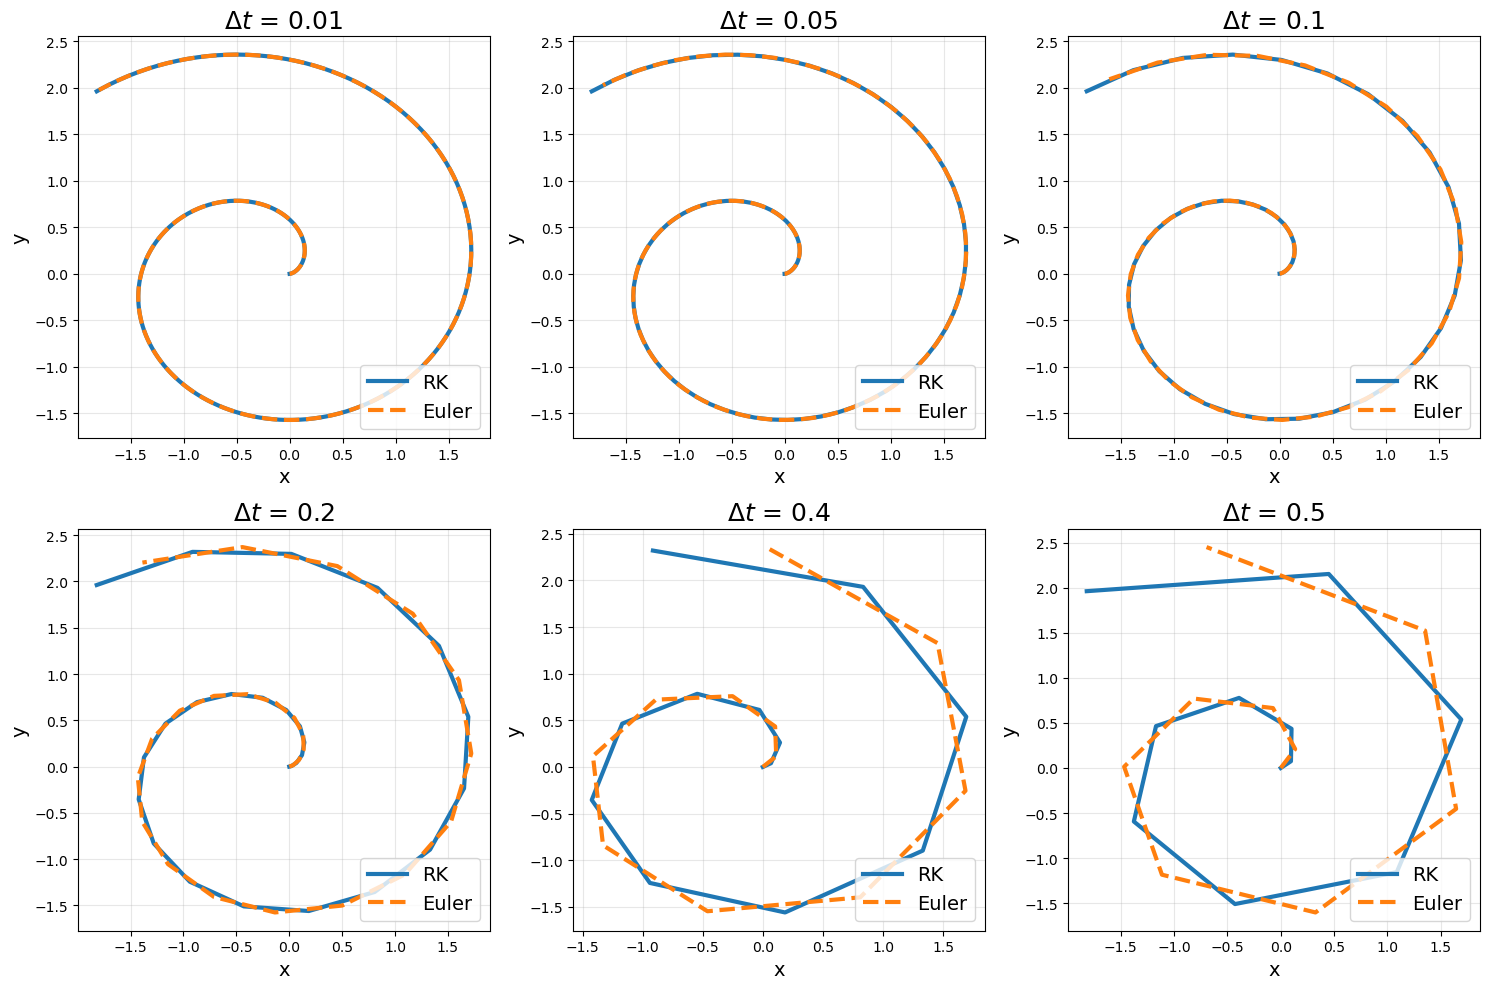

In [54]:
initial_state = jnp.array([0.0, 0.0, 0.0, 0.0])
control = jnp.array([2.0, 1.0])  # constant control over the entire horizon
dts = [0.01, 0.05, 0.1, 0.2, 0.4, 0.5]
time_horizon = 5  # seconds
integration_names = ["RK", "Euler"]
integration_funcs = [runge_kutta_integrate, euler_integrate]
linestyles = ["-", "--"]
colors = ["C0", "C1"]
linewidth = 3
fontsize = 18

grid_size = max(1, math.ceil(len(dts) / 3)), min(3, len(dts))

plt.figure(figsize=(15, 5 * grid_size[0]))
for integration_func, integration_name, linestyle, color in zip(
    integration_funcs, integration_names, linestyles, colors
):
    for i, dt in enumerate(dts):
        plt.subplot(*grid_size, i + 1)

        # TODO: Implement the dynamics simulation here and plot the trajectory
        ###### add your code here
        # dynamics = 
        # trajectory = ...
        # plot trajectory...

        n_timesteps = int(time_horizon/dt)
        control_sequence = jnp.tile(control, (n_timesteps, 1))
        dynamics = Dynamics(integration_func(continuous_dynamics, dt), state_dim, control_dim)
        trajectory = simulate_dynamics(dynamics, initial_state, control_sequence, dt)
        plot_trajectory(trajectory, integration_name, linestyle, color)

        ###### end of add your code here
    

        plt.legend(fontsize=fontsize - 4, loc="lower right")
        plt.title(f"$\\Delta t$ = {dt}", fontsize=fontsize)
        plt.xlabel("x", fontsize=fontsize - 4)
        plt.ylabel("y", fontsize=fontsize - 4)
    plt.tight_layout()


### (e) Vectorized simulation with `jax.vmap`

In many scenarios, you may want to simulate multiple trajectories in parallel, each starting from a different initial state and/or using different control sequences.

In this exercise, you will use the provided parameter values to simulate a batch of trajectories using JAX's `vmap` function for efficient, parallel computation. Then, visualize the resulting trajectories on a single plot.

In [55]:
bs = 1024 # number of trajectories to simulate
time_horizon = 5  # seconds
dt = 0.1 # time step
n_steps = int(time_horizon / dt) # number of steps to simulate

key = jax.random.PRNGKey(0) # random key
initial_states = jnp.array(jax.random.uniform(key, (bs, state_dim))) # initial states
control_sequences = jnp.array(jax.random.uniform(key, (bs, n_steps, control_dim))) # control sequences
dynamics = Dynamics(
    runge_kutta_integrate(continuous_dynamics, dt), state_dim, control_dim
)


(1024, 51, 4)

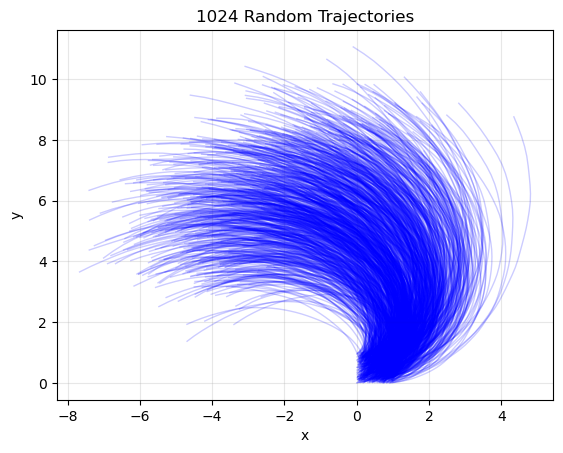

In [56]:
# TODO: use `jax.vmap` to simulate all trajectories and plot

###### add your code here
simulate_trajectories = jax.vmap(simulate_dynamics, in_axes=(None,0,0,None))
trajectories = simulate_trajectories(dynamics, initial_states, control_sequences, dt)
for traj in trajectories:
    plot_trajectory(traj, "RK4", '-', 'b', linewidth=1, alpha=0.2)
plt.title(f"{trajectories.shape[0]} Random Trajectories")
plt.xlabel("x")
plt.ylabel("y")
###### end of your code here


trajectories.shape

Let's also time how long it took to generate 1048 trajectories...


In [57]:
%timeit jax.vmap(simulate_dynamics, in_axes=(None, 0, 0, None))(discrete_dynamics_rk, initial_states, control_sequences, dt).block_until_ready()

4.97 ms ± 80.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### (f) Linearization of Dynamics Along Multiple Trajectories in Parallel

In many control applications, we want to linearize the nonlinear dynamics around a reference or "nominal" trajectory. This allows us to use linear control techniques locally, even when the true system dynamics are nonlinear.

The first-order Taylor expansion of the dynamics $f$ at a point $(x_k, u_k)$ is:
$$
    f(x, u, t_k) \approx f(x_k, u_k, t_k)
    + \nabla_x f(x_k, u_k, t_k) (x - x_k)
    + \nabla_u f(x_k, u_k, t_k) (u - u_k)
    = A x + B u + C
$$
where:
- $A = \nabla_x f(x_k, u_k, t_k)$ is the Jacobian of $f$ with respect to state, evaluated at $(x_k, u_k, t_k)$,
- $B = \nabla_u f(x_k, u_k, t_k)$ is the Jacobian of $f$ with respect to control, evaluated at $(x_k, u_k, t_k)$,
- $C = f(x_k, u_k, t_k) - A x_k - B u_k$ is the bias term.

To efficiently linearize the dynamics at multiple points along a trajectory, we can use JAX's automatic differentiation and batching capabilities:

- First, use `jax.jacobian` to create a function `linearize_dynamics_at_state` that computes $A$, $B$, and $C$ for a given state, control, and time.
- Then, using `linearize_dynamics_at_state` together with `jax.vmap`, implement a function `linearize_dynamics_along_trajectory` that computes $A$, $B$, and $C$ at each time step along an entire trajectory in parallel.

Your task:
- Implement `linearize_dynamics_at_state` using `jax.jacobian`.
- Implement `linearize_dynamics_along_trajectory` using `jax.vmap` and your previous function.

In [58]:
initial_state = jnp.array([0.0, 0.0, 0.0, 0.0])
time_horizon = 5  # seconds
dt = 0.1 # time step
n_steps = int(time_horizon / dt) # number of steps to simulate
ts = jnp.arange(0, time_horizon, dt)
control_sequence = jnp.array([[2.0, 1.0]] * n_steps)  # constant control over the entire horizon
trajectory = simulate_dynamics(dynamics, initial_state, control_sequence, dt)

In [59]:
# TODO: linearize the dynamics at each state in the trajectory
#### add your code here
J_x = jax.jacobian(dynamics, 0) # wrt state
J_u = jax.jacobian(dynamics, 1) # wrt control
@eqx.filter_jit
def linearize_dynamics_at_state(dynamics, state, control, time=None):
    A = J_x(state, control, time)
    B = J_u(state, control, time)
    C = dynamics(state, control, time) - A@state - B@control
    return A, B, C

# need a nested vmap; one outer to map over the batch of trajectories and 
# one inner vmap to map over every time step in each trajectory.
# after the first mapping, trajectories will be (51,4), 
# so we can map over ther first (0th) axis to map over the timesteps
linearize_dynamics_along_trajectory = eqx.filter_jit( 
    jax.vmap( 
        jax.vmap(
            linearize_dynamics_at_state, (None,0,0,None)
        ),(None,0,0,None)
    ))
###### end of add your code here




### (g) Now, compute the $A, B, C$ for a *batched* trajectory and control sequence.
We will use the `trajectories` and `control_sequences` from part (e).


In [60]:
trajectories.shape, control_sequences.shape

((1024, 51, 4), (1024, 50, 2))

In [61]:
# TODO: compute the A, B, C for a batched trajectory and control sequence
### add your code here
t = 0.0
As, Bs, Cs = linearize_dynamics_along_trajectory(dynamics, trajectories[:,:-1], control_sequences, t)
### end of add your code here



Congratulations! You have just learned some of the most powerful features of `JAX` and how they can be leveraged for simulating and linearizing dynamics in batches!